<a href="https://colab.research.google.com/github/Harini162006/harini-codebooster-2026/blob/main/Day2/mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv('student_performance.csv')

In [3]:
conn=sqlite3.connect('college.db')
cursor = conn.cursor()

df.to_sql("students", conn, if_exists="replace", index=False)

   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2       

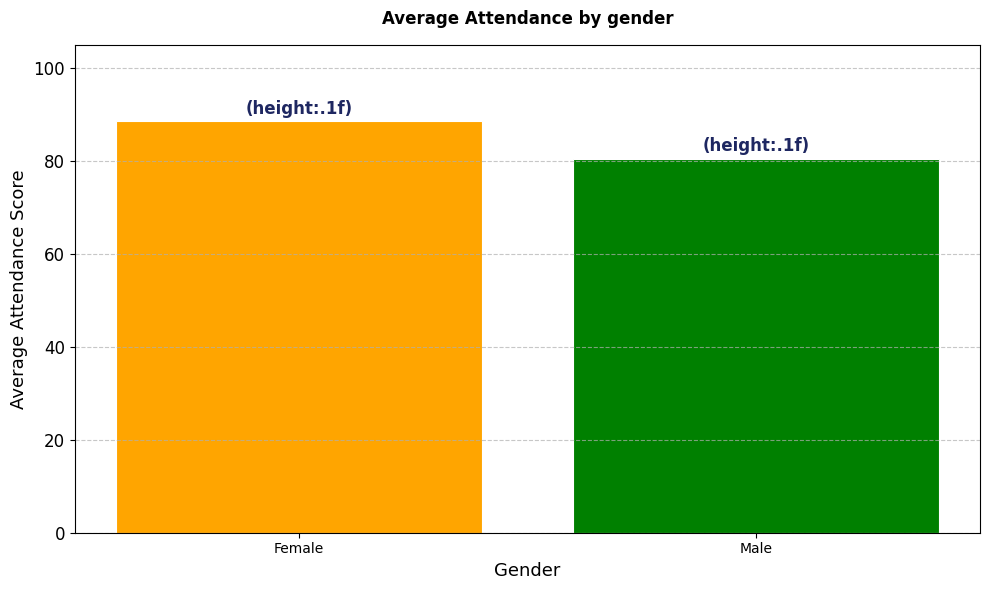

In [7]:
chart1_sql = """
SELECT gender, ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY gender
ORDER BY avg_attendance DESC
"""
chart1_data =  pd.read_sql_query(chart1_sql,conn)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['orange','green']
bars = ax.bar(chart1_data['gender'],
              chart1_data['avg_attendance'],
              color=bar_colors,
              edgecolor = 'white',
              linewidth = 0.8)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.8,
        f'(height:.1f)',
        ha='center', va='bottom',
        fontsize = 12, fontweight = 'bold',
        color = '#1E2761')

ax.set_xlabel('Gender', fontsize = 13)
ax.set_ylabel('Average Attendance Score', fontsize = 13)
ax.set_title('Average Attendance by gender',fontsize = 12, fontweight = 'bold', pad = 15)
ax.set_ylim(0,105)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()